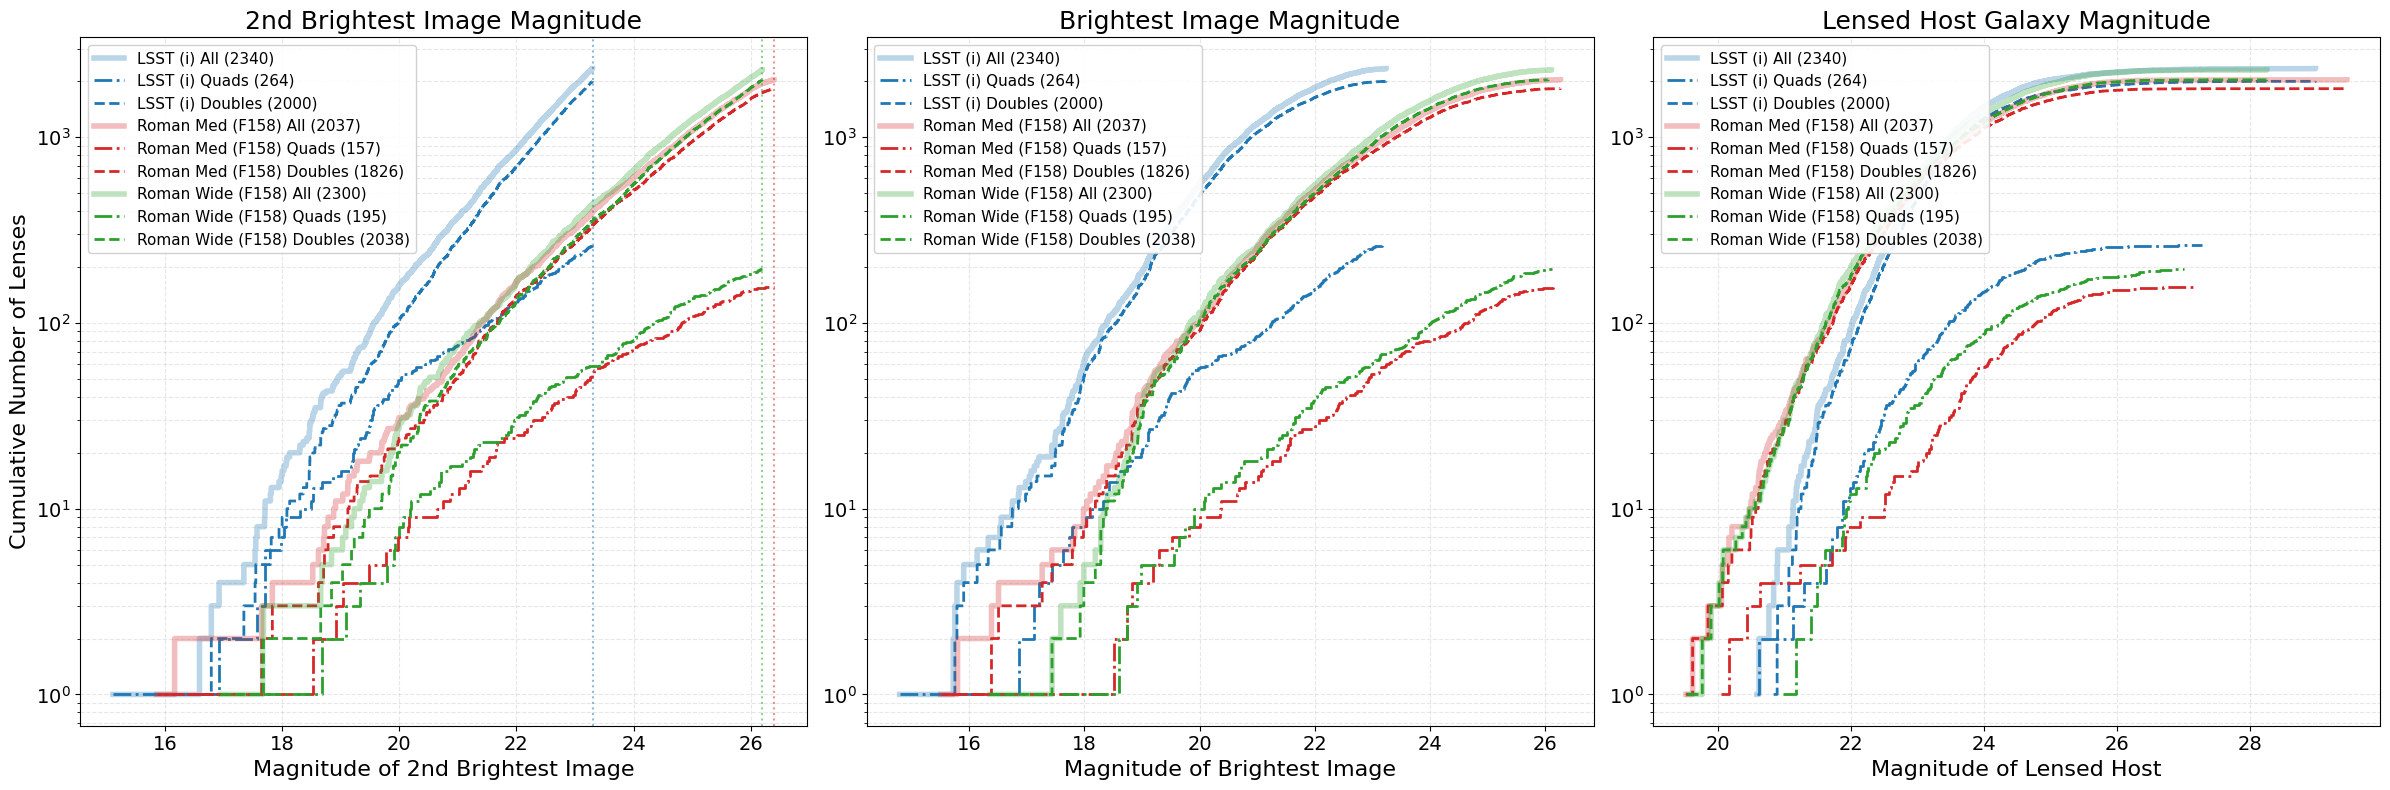

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# Set the paths relative to the 'extra' directory
DATA_DIR = "../data"
FIGURE_DIR = "../figures"

# Load the generated FITS catalogs
lsst_cat_path = os.path.join(DATA_DIR, "lsst_lensed_agn_catalog.fits")
roman_med_cat_path = os.path.join(DATA_DIR, "roman_medium_lensed_agn_catalog.fits")
roman_wide_cat_path = os.path.join(DATA_DIR, "roman_wide_lensed_agn_catalog.fits")

lsst_cat = Table.read(lsst_cat_path) if os.path.exists(lsst_cat_path) else None
roman_med_cat = Table.read(roman_med_cat_path) if os.path.exists(roman_med_cat_path) else None
roman_wide_cat = Table.read(roman_wide_cat_path) if os.path.exists(roman_wide_cat_path) else None

def get_valid_mags(catalog, col_name, num_images_filter=None):
    """Safely extracts valid magnitudes, optionally filtering by number of images."""
    if catalog is None or col_name not in catalog.colnames:
        return np.array([])
    
    # Apply filter for Quads (4) or Doubles (2)
    if num_images_filter is not None and 'num_images' in catalog.colnames:
        mask = catalog['num_images'] == num_images_filter
        mags = np.array(catalog[col_name][mask])
    else:
        mags = np.array(catalog[col_name])
        
    return mags[~np.isnan(mags) & np.isfinite(mags)]

def plot_cumulative_panel(ax, col_template, title, xlabel, show_limits=False):
    """Helper function to plot cumulative distributions (All, Quads, Doubles)."""
    
    surveys = [
        ("LSST (i)", lsst_cat, "i", 'tab:blue'),
        ("Roman Med (F158)", roman_med_cat, "F158", 'tab:red'),
        ("Roman Wide (F158)", roman_wide_cat, "F158", 'tab:green')
    ]
    
    for name, cat, band, color in surveys:
        if cat is None: continue
        col_name = col_template.format(band)
        
        # --- Plot ALL Lenses ---
        mags_all = get_valid_mags(cat, col_name)
        if len(mags_all) > 0:
            sorted_all = np.sort(mags_all)
            counts_all = np.arange(1, len(sorted_all) + 1)
            ax.step(sorted_all, counts_all, label=f"{name} All ({len(mags_all)})", 
                    color=color, linewidth=4, linestyle='-', alpha=0.3, where='post')
            
            # --- Plot Limits (based on the deepest magnitude of all lenses) ---
            if show_limits:
                limit = np.max(mags_all)
                ax.axvline(x=limit, color=color, linestyle=':', alpha=0.5)

        # --- Plot Quads ---
        mags_quad = get_valid_mags(cat, col_name, num_images_filter=4)
        if len(mags_quad) > 0:
            sorted_quads = np.sort(mags_quad)
            counts_quads = np.arange(1, len(sorted_quads) + 1)
            ax.step(sorted_quads, counts_quads, label=f"{name} Quads ({len(mags_quad)})", 
                    color=color, linewidth=2, linestyle='-.', where='post')

        # --- Plot Doubles ---
        mags_double = get_valid_mags(cat, col_name, num_images_filter=2)
        if len(mags_double) > 0:
            sorted_doubles = np.sort(mags_double)
            counts_doubles = np.arange(1, len(sorted_doubles) + 1)
            ax.step(sorted_doubles, counts_doubles, label=f"{name} Doubles ({len(mags_double)})", 
                    color=color, linewidth=2, linestyle='--', where='post')

    # Formatting
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=16)
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('Cumulative Number of Lenses', fontsize=16)
    
    ax.set_title(title, fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, which="both", ls="--", alpha=0.3)
    
    # Adjust legend so it fits all 9 lines cleanly
    ax.legend(fontsize=11, loc='upper left', framealpha=0.9, ncol=1)

# Set up the 1x3 plot figure
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Panel 1: Second Brightest Image (Depth Limit)
plot_cumulative_panel(
    ax=axes[0], 
    col_template="second_brightest_image_ps_mag_{}", 
    title="2nd Brightest Image Magnitude", 
    xlabel="Magnitude of 2nd Brightest Image",
    show_limits=True
)

# Panel 2: Brightest Image
plot_cumulative_panel(
    ax=axes[1], 
    col_template="brightest_image_ps_mag_{}", 
    title="Brightest Image Magnitude", 
    xlabel="Magnitude of Brightest Image",
    show_limits=False
)

# Panel 3: Lensed Host Galaxy
plot_cumulative_panel(
    ax=axes[2], 
    col_template="lensed_host_mag_{}", 
    title="Lensed Host Galaxy Magnitude", 
    xlabel="Magnitude of Lensed Host",
    show_limits=False
)

plt.tight_layout()

# Save and display
os.makedirs(FIGURE_DIR, exist_ok=True)
plt.savefig(os.path.join(FIGURE_DIR, "cumulative_lenses_all_quads_doubles.png"), dpi=300, bbox_inches='tight')
plt.show()

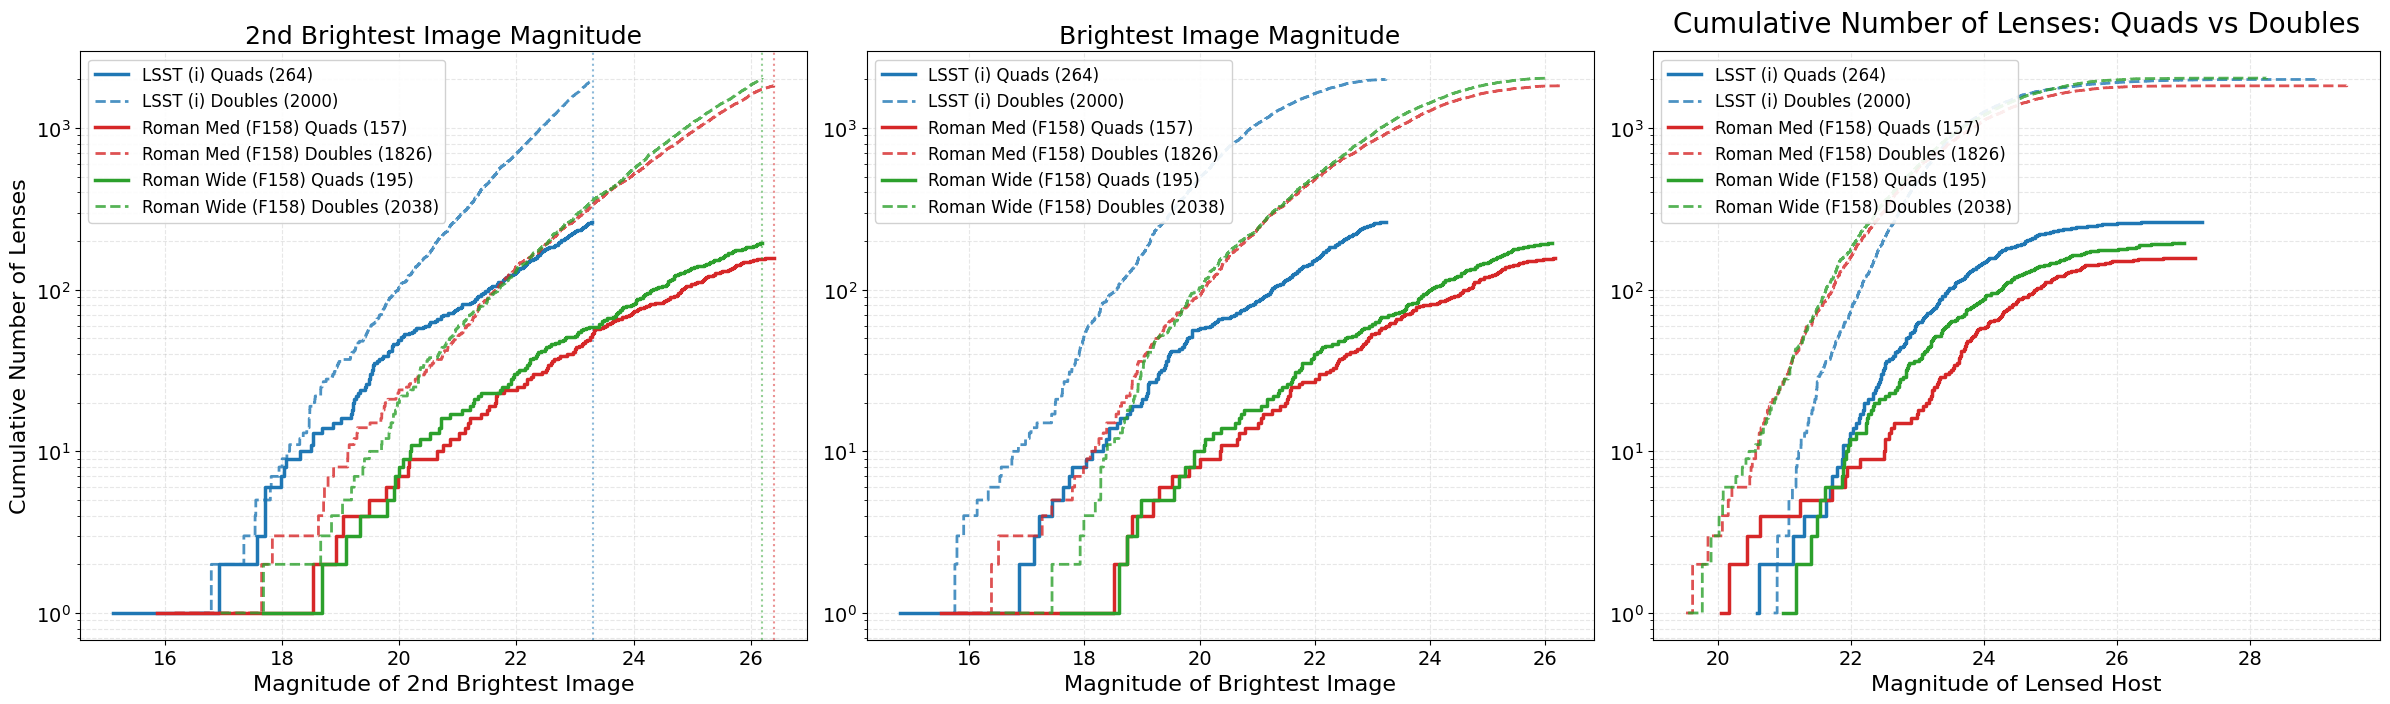

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# Set the paths relative to the 'extra' directory
DATA_DIR = "../data"
FIGURE_DIR = "../figures"

# Load the generated FITS catalogs
lsst_cat_path = os.path.join(DATA_DIR, "lsst_lensed_agn_catalog.fits")
roman_med_cat_path = os.path.join(DATA_DIR, "roman_medium_lensed_agn_catalog.fits")
roman_wide_cat_path = os.path.join(DATA_DIR, "roman_wide_lensed_agn_catalog.fits")

lsst_cat = Table.read(lsst_cat_path) if os.path.exists(lsst_cat_path) else None
roman_med_cat = Table.read(roman_med_cat_path) if os.path.exists(roman_med_cat_path) else None
roman_wide_cat = Table.read(roman_wide_cat_path) if os.path.exists(roman_wide_cat_path) else None

def get_valid_mags(catalog, col_name, num_images_filter=None):
    """Safely extracts valid magnitudes, optionally filtering by number of images."""
    if catalog is None or col_name not in catalog.colnames:
        return np.array([])
    
    # Apply filter for Quads (4) or Doubles (2)
    if num_images_filter is not None and 'num_images' in catalog.colnames:
        mask = catalog['num_images'] == num_images_filter
        mags = np.array(catalog[col_name][mask])
    else:
        mags = np.array(catalog[col_name])
        
    return mags[~np.isnan(mags) & np.isfinite(mags)]

def plot_cumulative_panel(ax, col_template, title, xlabel, show_limits=False):
    """Helper function to plot a cumulative distribution panel separated by quads and doubles."""
    
    surveys = [
        ("LSST (i)", lsst_cat, "i", 'tab:blue'),
        ("Roman Med (F158)", roman_med_cat, "F158", 'tab:red'),
        ("Roman Wide (F158)", roman_wide_cat, "F158", 'tab:green')
    ]
    
    for name, cat, band, color in surveys:
        if cat is None: continue
        col_name = col_template.format(band)
        
        # --- Plot Quads ---
        mags_quad = get_valid_mags(cat, col_name, num_images_filter=4)
        if len(mags_quad) > 0:
            sorted_quads = np.sort(mags_quad)
            counts_quads = np.arange(1, len(sorted_quads) + 1)
            ax.step(sorted_quads, counts_quads, label=f"{name} Quads ({len(mags_quad)})", 
                    color=color, linewidth=2.5, linestyle='-', where='post')

        # --- Plot Doubles ---
        mags_double = get_valid_mags(cat, col_name, num_images_filter=2)
        if len(mags_double) > 0:
            sorted_doubles = np.sort(mags_double)
            counts_doubles = np.arange(1, len(sorted_doubles) + 1)
            ax.step(sorted_doubles, counts_doubles, label=f"{name} Doubles ({len(mags_double)})", 
                    color=color, linewidth=2, linestyle='--', alpha=0.8, where='post')
            
        # --- Plot Limits (based on the deepest magnitude overall) ---
        if show_limits:
            all_mags = get_valid_mags(cat, col_name)
            if len(all_mags) > 0:
                limit = np.max(all_mags)
                ax.axvline(x=limit, color=color, linestyle=':', alpha=0.5)

    # Formatting
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=16) # Increased from 12
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('Cumulative Number of Lenses', fontsize=16) # Increased from 12
    
    ax.set_title(title, fontsize=18) # Increased from 14
    ax.tick_params(axis='both', which='major', labelsize=14) # Increased from 10
    ax.grid(True, which="both", ls="--", alpha=0.3)
    
    # Adjust legend so it's readable but doesn't overwhelm the plot
    ax.legend(fontsize=12, loc='upper left', framealpha=0.9) # Increased from 9

# Set up the 1x3 plot figure
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Panel 1: Second Brightest Image (Depth Limit)
plot_cumulative_panel(
    ax=axes[0], 
    col_template="second_brightest_image_ps_mag_{}", 
    title="2nd Brightest Image Magnitude", 
    xlabel="Magnitude of 2nd Brightest Image",
    show_limits=True
)

# Panel 2: Brightest Image
plot_cumulative_panel(
    ax=axes[1], 
    col_template="brightest_image_ps_mag_{}", 
    title="Brightest Image Magnitude", 
    xlabel="Magnitude of Brightest Image",
    show_limits=False
)

# Panel 3: Lensed Host Galaxy
plot_cumulative_panel(
    ax=axes[2], 
    col_template="lensed_host_mag_{}", 
    title="Lensed Host Galaxy Magnitude", 
    xlabel="Magnitude of Lensed Host",
    show_limits=False
)

plt.tight_layout()

plt.title("Cumulative Number of Lenses: Quads vs Doubles", fontsize=20, y=1.02)

# Save and display
os.makedirs(FIGURE_DIR, exist_ok=True)
plt.savefig(os.path.join(FIGURE_DIR, "cumulative_lenses_quads_vs_doubles.png"), dpi=300, bbox_inches='tight')
plt.show()

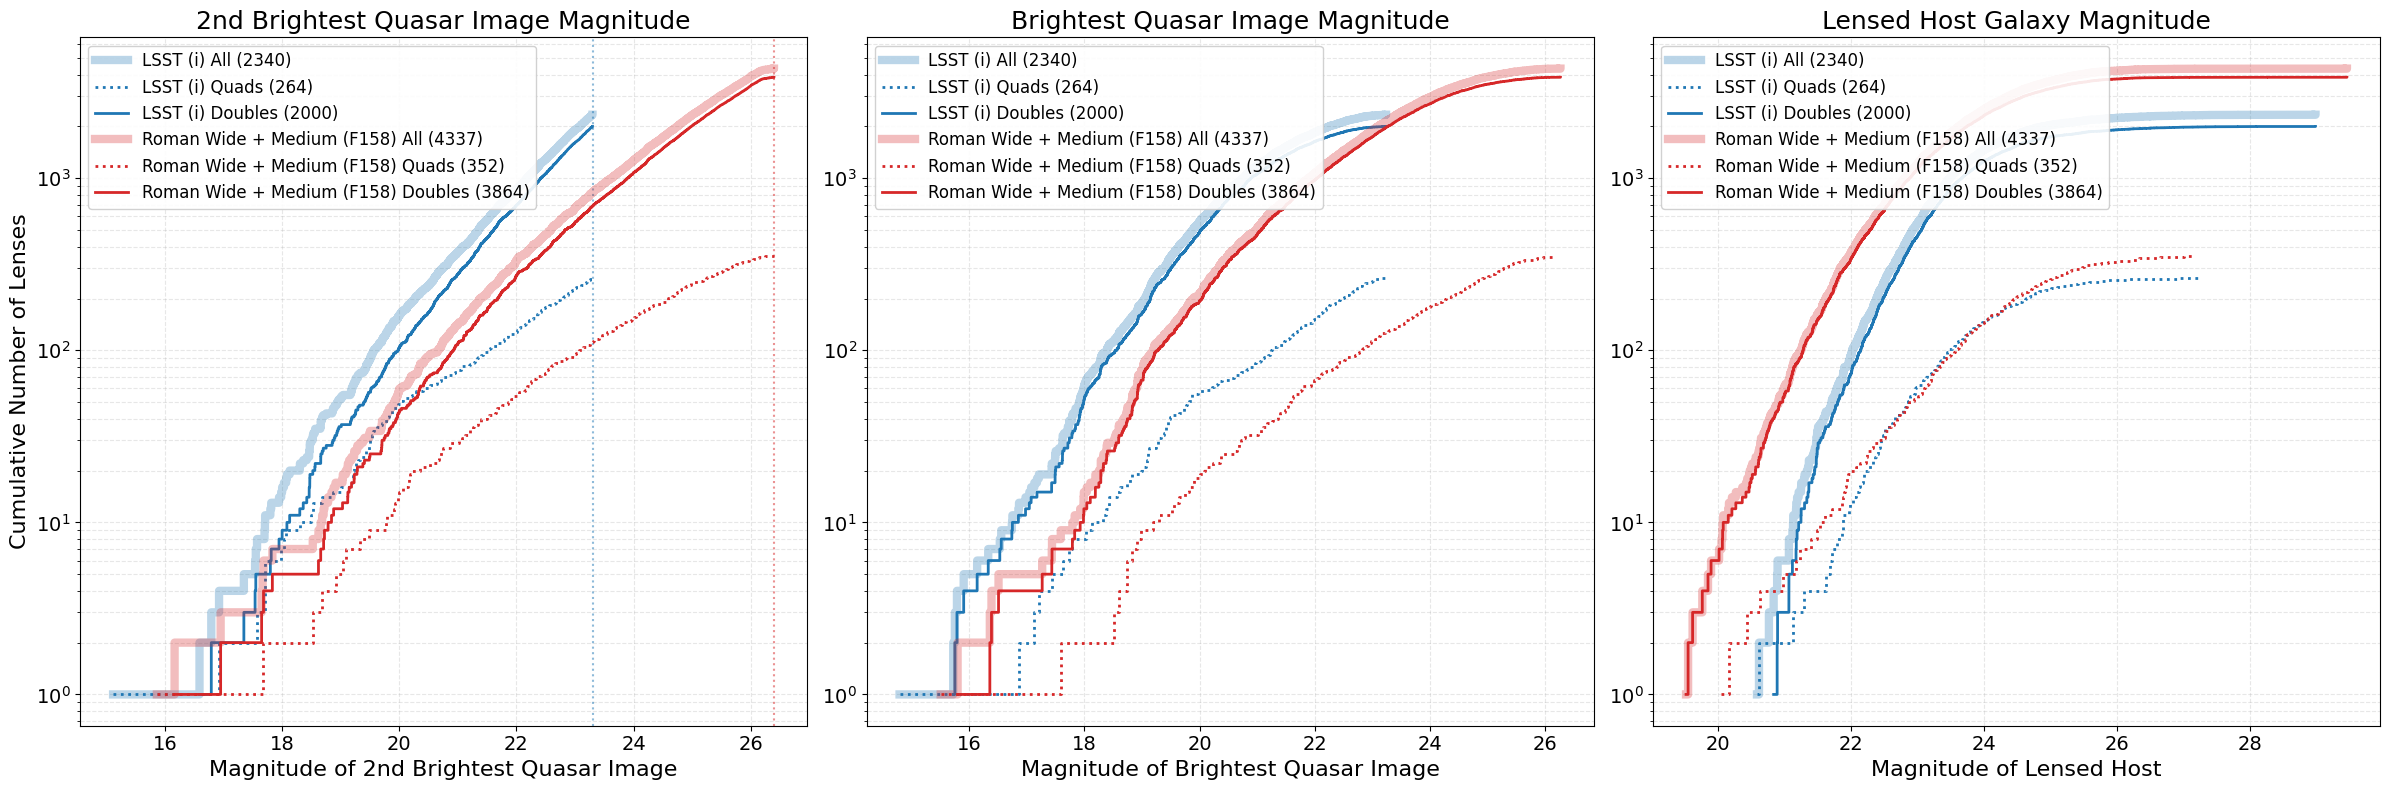

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack

# Set the paths relative to the 'extra' directory
DATA_DIR = "../data"
FIGURE_DIR = "../figures"

# Load the generated FITS catalogs
lsst_cat_path = os.path.join(DATA_DIR, "lsst_lensed_agn_catalog.fits")
roman_med_cat_path = os.path.join(DATA_DIR, "roman_medium_lensed_agn_catalog.fits")
roman_wide_cat_path = os.path.join(DATA_DIR, "roman_wide_lensed_agn_catalog.fits")

lsst_cat = Table.read(lsst_cat_path) if os.path.exists(lsst_cat_path) else None
roman_med_cat = Table.read(roman_med_cat_path) if os.path.exists(roman_med_cat_path) else None
roman_wide_cat = Table.read(roman_wide_cat_path) if os.path.exists(roman_wide_cat_path) else None

# Combine the Roman catalogs
roman_combined_cat = None
roman_cats_to_combine = [cat for cat in [roman_med_cat, roman_wide_cat] if cat is not None]
if len(roman_cats_to_combine) > 0:
    roman_combined_cat = vstack(roman_cats_to_combine)

def get_valid_mags(catalog, col_name, num_images_filter=None):
    """Safely extracts valid magnitudes, optionally filtering by number of images."""
    if catalog is None or col_name not in catalog.colnames:
        return np.array([])
    
    # Apply filter for Quads (4) or Doubles (2)
    if num_images_filter is not None and 'num_images' in catalog.colnames:
        mask = catalog['num_images'] == num_images_filter
        mags = np.array(catalog[col_name][mask])
    else:
        mags = np.array(catalog[col_name])
        
    return mags[~np.isnan(mags) & np.isfinite(mags)]

def plot_cumulative_panel(ax, col_template, title, xlabel, show_limits=False):
    """Helper function to plot cumulative distributions (All, Quads, Doubles)."""
    
    surveys = [
        ("LSST (i)", lsst_cat, "i", 'tab:blue'),
        ("Roman Wide + Medium (F158)", roman_combined_cat, "F158", 'tab:red')
    ]
    
    for name, cat, band, color in surveys:
        if cat is None: continue
        col_name = col_template.format(band)
        
        # --- Plot ALL Lenses ---
        mags_all = get_valid_mags(cat, col_name)
        if len(mags_all) > 0:
            sorted_all = np.sort(mags_all)
            counts_all = np.arange(1, len(sorted_all) + 1)
            ax.step(sorted_all, counts_all, label=f"{name} All ({len(mags_all)})", 
                    color=color, linewidth=6, linestyle='-', alpha=0.3, where='post')
            
            # --- Plot Limits (based on the deepest magnitude of all lenses) ---
            if show_limits:
                limit = np.max(mags_all)
                ax.axvline(x=limit, color=color, linestyle=':', alpha=0.5)

        # --- Plot Quads ---
        mags_quad = get_valid_mags(cat, col_name, num_images_filter=4)
        if len(mags_quad) > 0:
            sorted_quads = np.sort(mags_quad)
            counts_quads = np.arange(1, len(sorted_quads) + 1)
            ax.step(sorted_quads, counts_quads, label=f"{name} Quads ({len(mags_quad)})", 
                    color=color, linewidth=2, linestyle=':', where='post')

        # --- Plot Doubles ---
        mags_double = get_valid_mags(cat, col_name, num_images_filter=2)
        if len(mags_double) > 0:
            sorted_doubles = np.sort(mags_double)
            counts_doubles = np.arange(1, len(sorted_doubles) + 1)
            ax.step(sorted_doubles, counts_doubles, label=f"{name} Doubles ({len(mags_double)})", 
                    color=color, linewidth=2, linestyle='-', where='post')

    # Formatting
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=16)
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('Cumulative Number of Lenses', fontsize=16)
    
    ax.set_title(title, fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, which="both", ls="--", alpha=0.3)
    
    # Adjust legend
    ax.legend(fontsize=12, loc='upper left', framealpha=0.9, ncol=1)

# Set up the 1x3 plot figure
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Panel 1: Second Brightest Image (Depth Limit)
plot_cumulative_panel(
    ax=axes[0], 
    col_template="second_brightest_image_ps_mag_{}", 
    title="2nd Brightest Quasar Image Magnitude", 
    xlabel="Magnitude of 2nd Brightest Quasar Image",
    show_limits=True
)

# Panel 2: Brightest Image
plot_cumulative_panel(
    ax=axes[1], 
    col_template="brightest_image_ps_mag_{}", 
    title="Brightest Quasar Image Magnitude", 
    xlabel="Magnitude of Brightest Quasar Image",
    show_limits=False
)

# Panel 3: Lensed Host Galaxy
plot_cumulative_panel(
    ax=axes[2], 
    col_template="lensed_host_mag_{}", 
    title="Lensed Host Galaxy Magnitude", 
    xlabel="Magnitude of Lensed Host",
    show_limits=False
)

plt.tight_layout()

# Save and display
os.makedirs(FIGURE_DIR, exist_ok=True)
# plt.savefig(os.path.join(FIGURE_DIR, "cumulative_lenses_lsst_vs_roman_combined.png"), dpi=300, bbox_inches='tight')
plt.show()

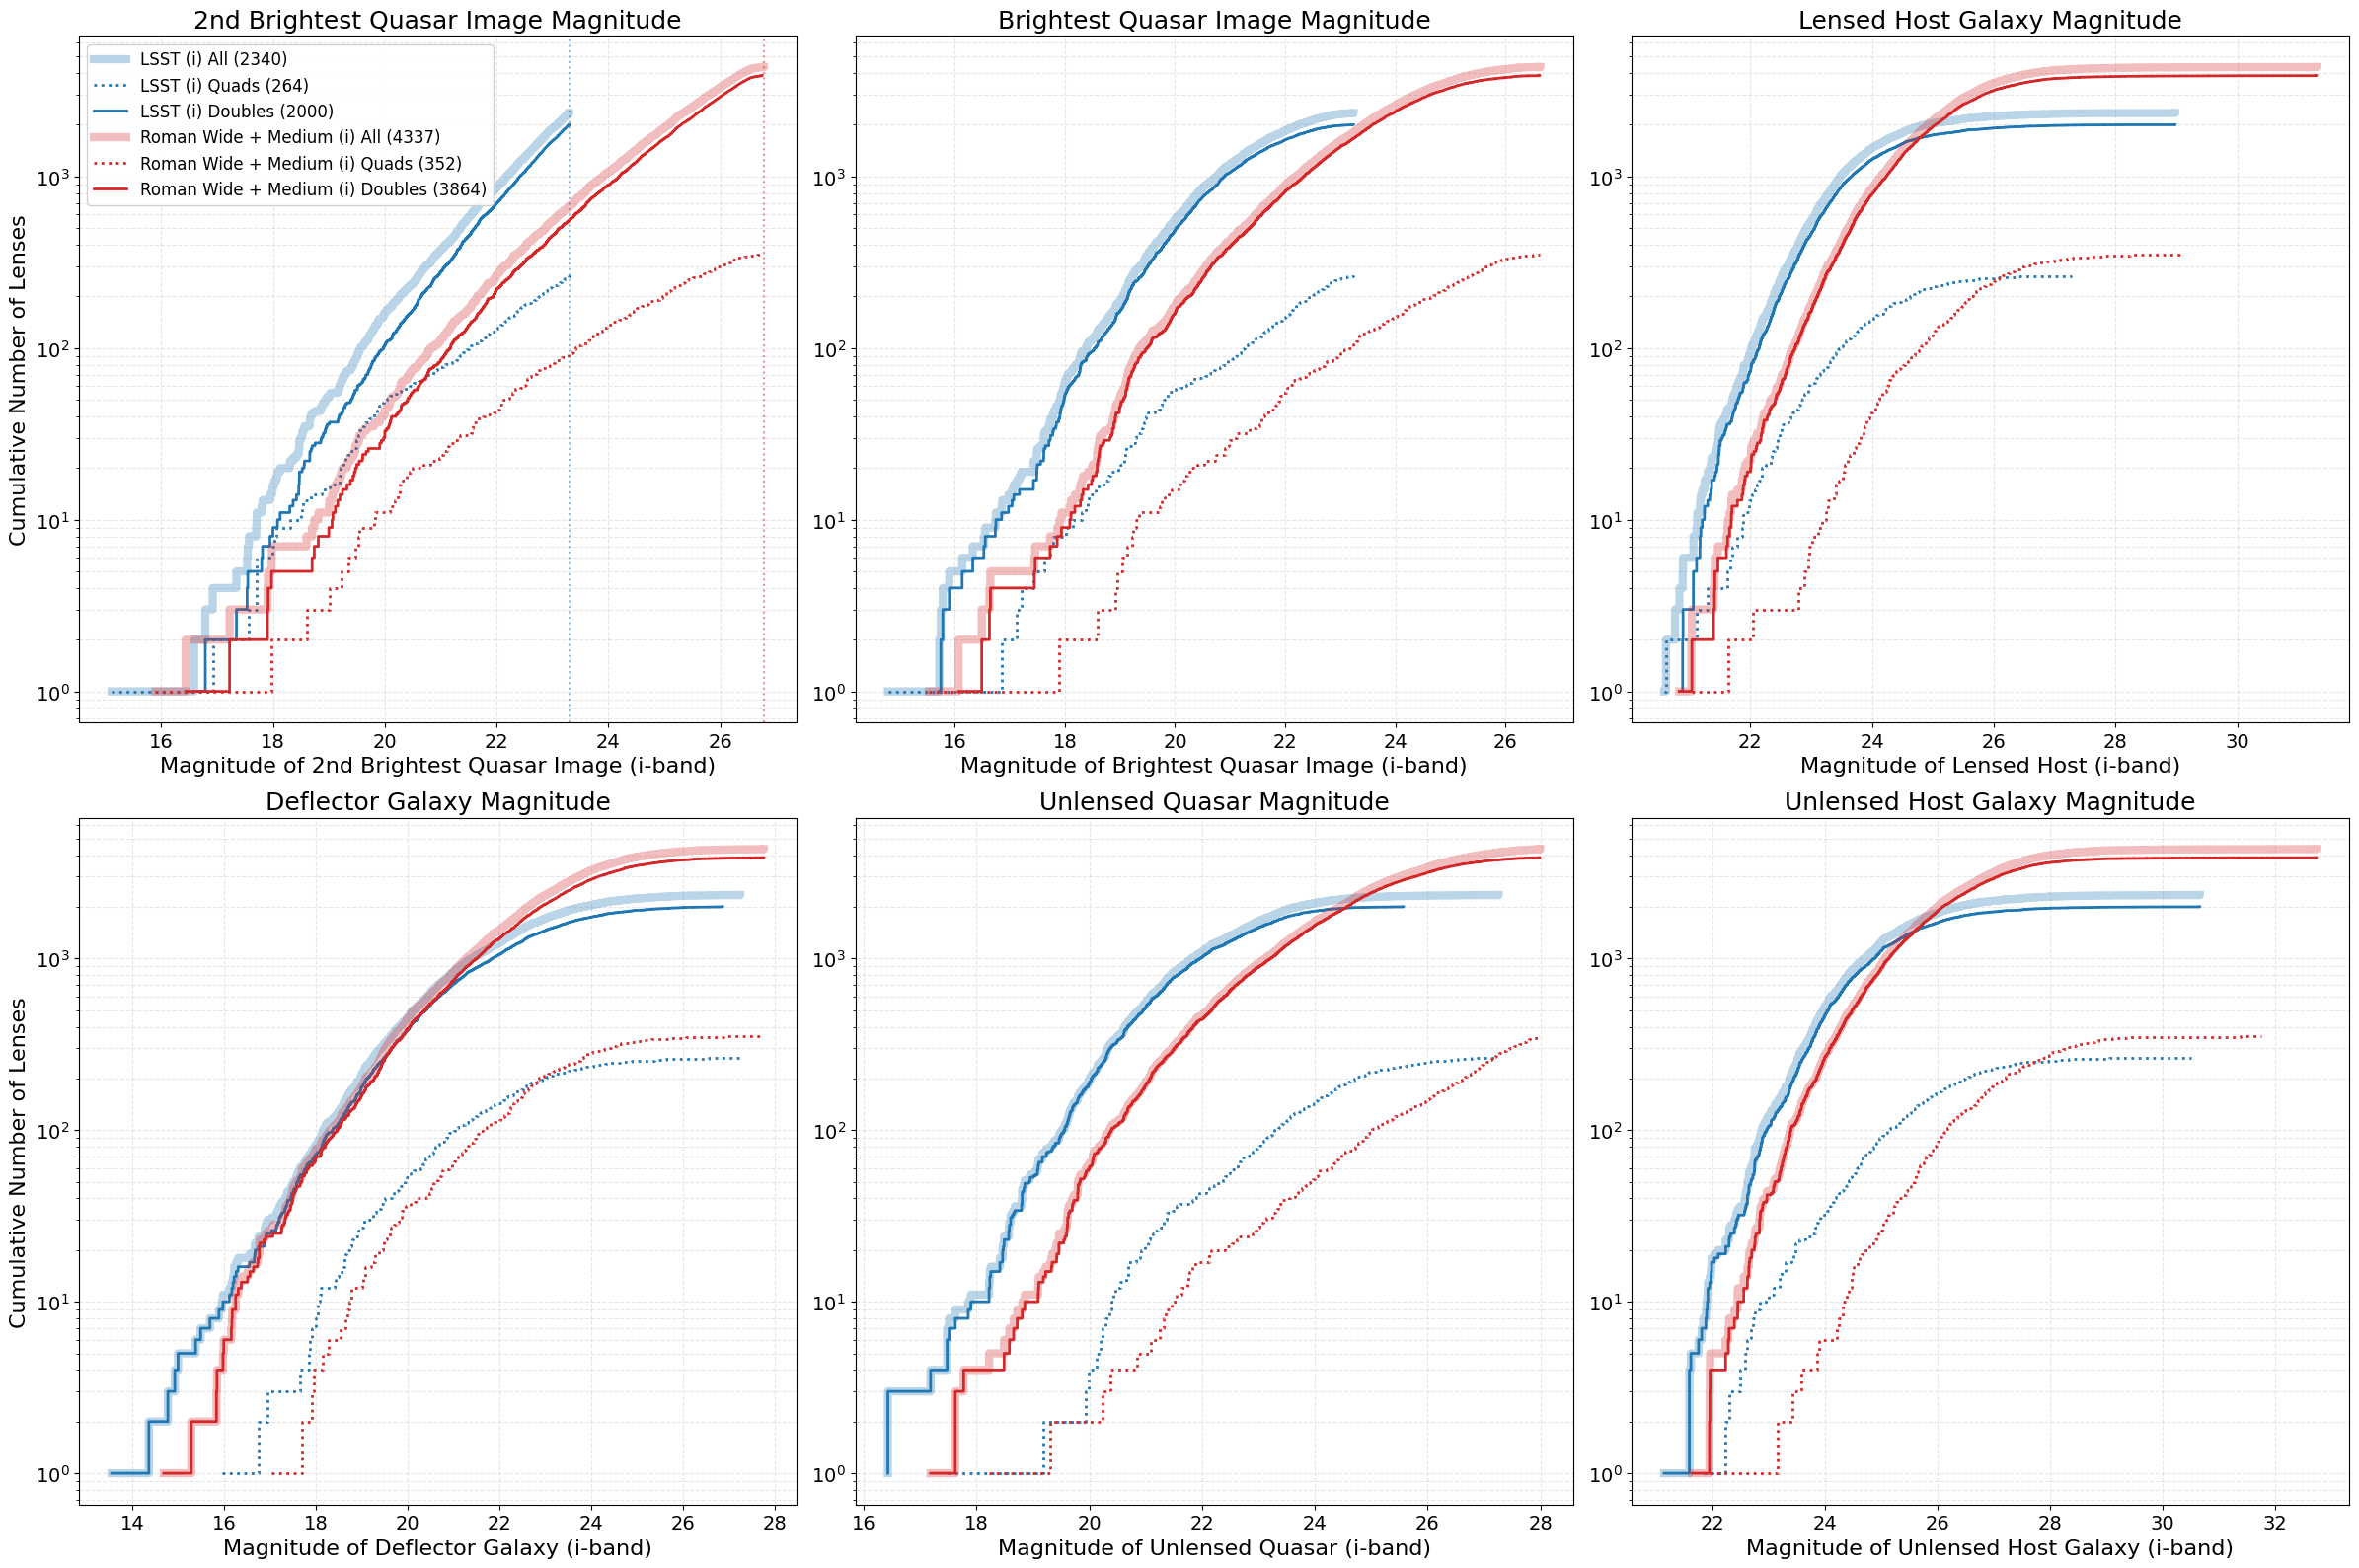

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack

# Set the paths relative to the 'extra' directory
DATA_DIR = "../data"
FIGURE_DIR = "../figures"

# Load the generated FITS catalogs
lsst_cat_path = os.path.join(DATA_DIR, "lsst_lensed_agn_catalog.fits")
roman_med_cat_path = os.path.join(DATA_DIR, "roman_medium_lensed_agn_catalog.fits")
roman_wide_cat_path = os.path.join(DATA_DIR, "roman_wide_lensed_agn_catalog.fits")

lsst_cat = Table.read(lsst_cat_path) if os.path.exists(lsst_cat_path) else None
roman_med_cat = Table.read(roman_med_cat_path) if os.path.exists(roman_med_cat_path) else None
roman_wide_cat = Table.read(roman_wide_cat_path) if os.path.exists(roman_wide_cat_path) else None

# Combine the Roman catalogs
roman_combined_cat = None
roman_cats_to_combine = [cat for cat in [roman_med_cat, roman_wide_cat] if cat is not None]
if len(roman_cats_to_combine) > 0:
    roman_combined_cat = vstack(roman_cats_to_combine)

def get_valid_mags(catalog, col_name, num_images_filter=None):
    """Safely extracts valid magnitudes, optionally filtering by number of images."""
    if catalog is None or col_name not in catalog.colnames:
        return np.array([])
    
    # Apply filter for Quads (4) or Doubles (2)
    if num_images_filter is not None and 'num_images' in catalog.colnames:
        mask = catalog['num_images'] == num_images_filter
        mags = np.array(catalog[col_name][mask])
    else:
        mags = np.array(catalog[col_name])
        
    return mags[~np.isnan(mags) & np.isfinite(mags)]

def plot_cumulative_panel(ax, col_template, title, xlabel, show_limits=False):
    """Helper function to plot cumulative distributions (All, Quads, Doubles)."""
    
    surveys = [
        ("LSST (i)", lsst_cat, "i", 'tab:blue'),
        ("Roman Wide + Medium (i)", roman_combined_cat, "i", 'tab:red')
    ]
    
    for name, cat, band, color in surveys:
        if cat is None: continue
        col_name = col_template.format(band)
        
        # --- Plot ALL Lenses ---
        mags_all = get_valid_mags(cat, col_name)
        if len(mags_all) > 0:
            sorted_all = np.sort(mags_all)
            counts_all = np.arange(1, len(sorted_all) + 1)
            ax.step(sorted_all, counts_all, label=f"{name} All ({len(mags_all)})", 
                    color=color, linewidth=6, linestyle='-', alpha=0.3, where='post')
            
            # --- Plot Limits (based on the deepest magnitude of all lenses) ---
            if show_limits:
                limit = np.max(mags_all)
                ax.axvline(x=limit, color=color, linestyle=':', alpha=0.5)

        # --- Plot Quads ---
        mags_quad = get_valid_mags(cat, col_name, num_images_filter=4)
        if len(mags_quad) > 0:
            sorted_quads = np.sort(mags_quad)
            counts_quads = np.arange(1, len(sorted_quads) + 1)
            ax.step(sorted_quads, counts_quads, label=f"{name} Quads ({len(mags_quad)})", 
                    color=color, linewidth=2, linestyle=':', where='post')

        # --- Plot Doubles ---
        mags_double = get_valid_mags(cat, col_name, num_images_filter=2)
        if len(mags_double) > 0:
            sorted_doubles = np.sort(mags_double)
            counts_doubles = np.arange(1, len(sorted_doubles) + 1)
            ax.step(sorted_doubles, counts_doubles, label=f"{name} Doubles ({len(mags_double)})", 
                    color=color, linewidth=2, linestyle='-', where='post')

    # Formatting
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=16)
    
    # Automatically add y-label to the left-most columns (Panels 1 and 4)
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('Cumulative Number of Lenses', fontsize=16)
    
    ax.set_title(title, fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, which="both", ls="--", alpha=0.3)
    
    # Adjust legend
    # ax.legend(fontsize=12, loc='upper left', framealpha=0.9, ncol=1)

# Set up the 2x3 plot figure
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
axes = axes.flatten() # Flatten so we can index 0-5 easily

# --- ROW 1 ---

# Panel 1: Second Brightest Image (Depth Limit)
plot_cumulative_panel(
    ax=axes[0], 
    col_template="second_brightest_image_ps_mag_{}", 
    title="2nd Brightest Quasar Image Magnitude", 
    xlabel="Magnitude of 2nd Brightest Quasar Image (i-band)",
    show_limits=True
)
axes[0].legend(fontsize=12, loc='upper left', framealpha=0.9, ncol=1)

# Panel 2: Brightest Image
plot_cumulative_panel(
    ax=axes[1], 
    col_template="brightest_image_ps_mag_{}", 
    title="Brightest Quasar Image Magnitude", 
    xlabel="Magnitude of Brightest Quasar Image (i-band)",
    show_limits=False
)

# Panel 3: Lensed Host Galaxy
plot_cumulative_panel(
    ax=axes[2], 
    col_template="lensed_host_mag_{}", 
    title="Lensed Host Galaxy Magnitude", 
    xlabel="Magnitude of Lensed Host (i-band)",
    show_limits=False
)

# --- ROW 2 ---

# Panel 4: Deflector Galaxy Magnitude
plot_cumulative_panel(
    ax=axes[3], 
    col_template="deflector_mag_{}", 
    title="Deflector Galaxy Magnitude", 
    xlabel="Magnitude of Deflector Galaxy (i-band)",
    show_limits=False
)

# Panel 5: Unlensed Quasar Magnitude
plot_cumulative_panel(
    ax=axes[4], 
    col_template="unlensed_ps_mag_{}", 
    title="Unlensed Quasar Magnitude", 
    xlabel="Magnitude of Unlensed Quasar (i-band)",
    show_limits=False
)

# Panel 6: Unlensed Host Galaxy Magnitude
plot_cumulative_panel(
    ax=axes[5], 
    col_template="unlensed_host_mag_{}", 
    title="Unlensed Host Galaxy Magnitude", 
    xlabel="Magnitude of Unlensed Host Galaxy (i-band)",
    show_limits=False
)

# add space between rows
plt.subplots_adjust(hspace=0.2)

plt.tight_layout()

# Save and display
os.makedirs(FIGURE_DIR, exist_ok=True)
# plt.savefig(os.path.join(FIGURE_DIR, "cumulative_lenses_6_panels.png"), dpi=300, bbox_inches='tight')
plt.show()